In [ ]:
#Initial Imports
from astropy.io import fits
from scipy.ndimage import median_filter
import numpy as np
from photutils.detection import DAOStarFinder
from scipy.optimize import curve_fit, linear_sum_assignment
import matplotlib.pyplot as plt
import math
import pandas as pd
import re
import matplotlib.colors as mcolors
import colorsys
import os


In [19]:
#Lists for fits file paths to be processed, as well as detector temps
#Entries in the temps list must correspond to and be in the same order as the images
output_csv = r"Dark_Current_Summary_Stats.csv"
filenames = [r"Y:\2D\20260406\iLocater_lab_20260406_0001_hxrgproc.fits",
r"Y:\2D\20260406\iLocater_lab_20260406_0002_hxrgproc.fits",
r"Y:\2D\20260407\iLocater_lab_20260407_0001_hxrgproc.fits",
r"Y:\2D\20260407\iLocater_lab_20260407_0002_hxrgproc.fits",
r"Y:\2D\20260409\iLocater_lab_20260409_0001_hxrgproc.fits",
r"Y:\2D\20260409\iLocater_lab_20260409_0002_hxrgproc.fits",
r"Y:\2D\20260410\iLocater_lab_20260410_0001_hxrgproc.fits",
r"Y:\2D\20260410\iLocater_lab_20260410_0002_hxrgproc.fits",
r"Y:\2D\20260411\iLocater_lab_20260411_0001_hxrgproc.fits",
r"Y:\2D\20260411\iLocater_lab_20260411_0002_hxrgproc.fits",
r"Y:\2D\20260412\iLocater_lab_20260412_0001_hxrgproc.fits",
r"Y:\2D\20260412\iLocater_lab_20260412_0002_hxrgproc.fits",
r"Y:\2D\20260413\iLocater_lab_20260413_0001_hxrgproc.fits",
r"Y:\2D\20260413\iLocater_lab_20260413_0002_hxrgproc.fits",
r"Y:\2D\20260414\iLocater_lab_20260414_0001_hxrgproc.fits",
r"Y:\2D\20260414\iLocater_lab_20260414_0002_hxrgproc.fits",
r"Y:\2D\20260415\iLocater_lab_20260415_0001_hxrgproc.fits",
r"Y:\2D\20260415\iLocater_lab_20260415_0002_hxrgproc.fits"]
temps = [130.738, 130.755, 121.429, 121.461, 102.087, 102.078, 95.8237, 95.8189, 90.8267, 90.8215, 88.1519, 88.1490, 86.4587, 86.4556, 84.8636, 84.8621, 83.7054, 83.7017]

In [ ]:
def process_amps(filenames, temps):
    rows = []
    for path, temp in zip(filenames, temps):
        data = fits.getdata(path)
        sections = np.split(data, 32, axis=1)
        
        #calculate summary stats for each amplifier
        for i, amp in enumerate(sections):
            n = np.size(amp)
            total = np.sum(amp)
            mean = np.mean(amp)
            std = np.std(amp)
            sem = std / np.sqrt(n)
            var = std**2

            rows.append({
                "Filename": os.path.basename(path),
                "Amp #": i + 1,
                "Temp": temp,
                "Total Readout": total,
                "Total Readout Uncertainty": n * sem,
                "Mean Readout (Per Pixel)": mean,
                "Standard Deviation (Per Pixel)": std,
                "Standard Error in the Pixel Mean": sem,
                "Variance (Per Pixel)": var
            })
    return pd.DataFrame(rows)

In [22]:
df = process_amps(filenames, temps)

In [29]:
print(df[df["Amp #"] == 1])

                                     Filename  Amp #      Temp  Total Readout  \
0    iLocater_lab_20260406_0001_hxrgproc.fits      1  130.7380  542786.312500   
32   iLocater_lab_20260406_0002_hxrgproc.fits      1  130.7550  253243.703125   
64   iLocater_lab_20260407_0001_hxrgproc.fits      1  121.4290  -56615.695312   
96   iLocater_lab_20260407_0002_hxrgproc.fits      1  121.4610   52627.410156   
128  iLocater_lab_20260409_0001_hxrgproc.fits      1  102.0870   -1104.792603   
160  iLocater_lab_20260409_0002_hxrgproc.fits      1  102.0780   17526.087891   
192  iLocater_lab_20260410_0001_hxrgproc.fits      1   95.8237    1895.450806   
224  iLocater_lab_20260410_0002_hxrgproc.fits      1   95.8189   14003.811523   
256  iLocater_lab_20260411_0001_hxrgproc.fits      1   90.8267  -18910.451172   
288  iLocater_lab_20260411_0002_hxrgproc.fits      1   90.8215   10114.535156   
320  iLocater_lab_20260412_0001_hxrgproc.fits      1   88.1519  -26903.724609   
352  iLocater_lab_20260412_0

In [32]:
even = np.arange(len(filenames)) % 2 == 0
odd = ~even
def plot_amp_vs_temp(amp_df, amp, even=even, odd=odd):
    t = amp_df["Temp"].to_numpy()
    y1 = amp_df["Total Readout"].to_numpy()
    y1err = amp_df["Total Readout Uncertainty"].to_numpy()
    y2 = amp_df["Mean Readout (Per Pixel)"].to_numpy()
    y2err = amp_df["Standard Error in the Pixel Mean"].to_numpy()

    fig, axes = plt.subplots(2, 1, sharex=True, figsize=(7,8))
    fig.suptitle(f"Stats By Temp for Amp #{amp}")

    #plot total readout data for short exposures (even) and long exposures (odd)
    axes[0].errorbar(t[even], y1[even], y1err[even], 
    c="darkgoldenrod", fmt="o", capsize=4, markersize=3, alpha=0.75, label="Short Exposure")
    axes[0].errorbar(t[odd], y1[odd], y1err[odd],
    c="darkslategrey", fmt="o", capsize=4, markersize=3, alpha=0.75, label="Long Exposure")
    axes[0].set_ylabel("Amp-Wide Dark Current (ADU/Frame)")
    axes[0].legend()

    #plot mean pixel readout, even and odd distinction is the same
    axes[1].errorbar(t[even], y2[even], y2err[even],
    c="mediumorchid", fmt="o", capsize=4, markersize=3, alpha=0.75, label="Short Exposure")
    axes[1].errorbar(t[odd], y2[odd], y2err[odd],
    c="olive", fmt="o", capsize=4, markersize=3, alpha=0.75, label="Long Exposure")
    axes[1].set_ylabel("Mean Pixel Dark Current (ADU/Pixel/Frame)")
    axes[1].set_xlabel("Detector Temp (K)")
    axes[1].legend()

    #display subplots
    plt.tight_layout()
    plt.show()



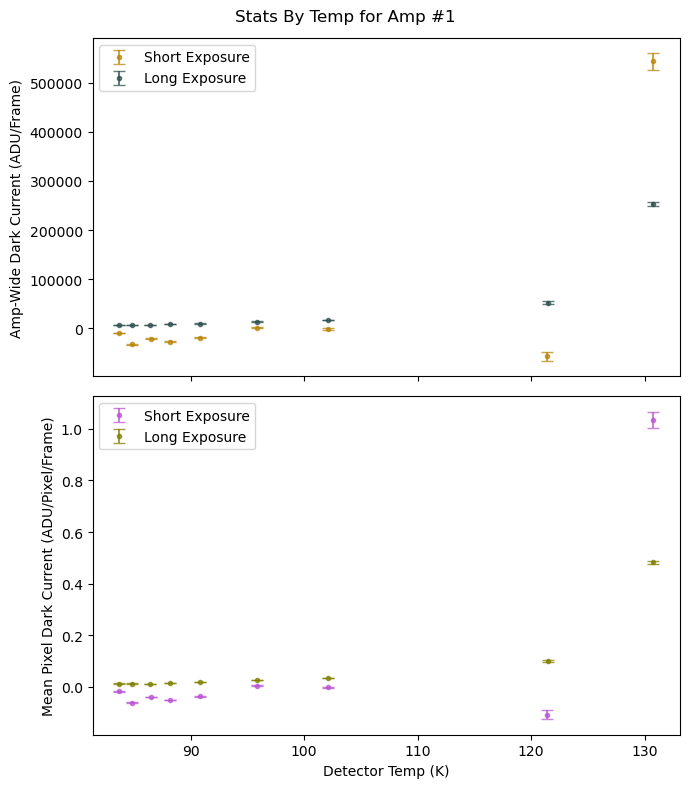

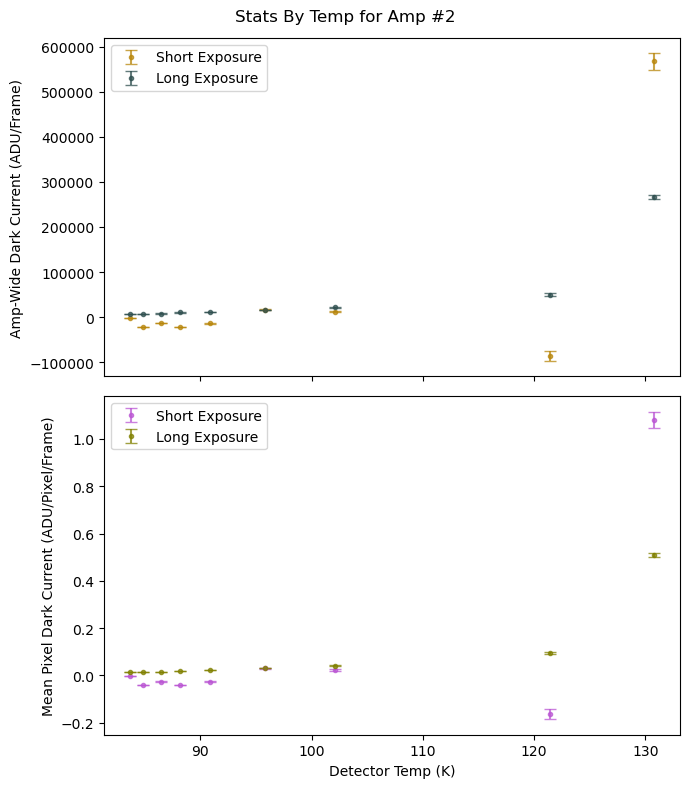

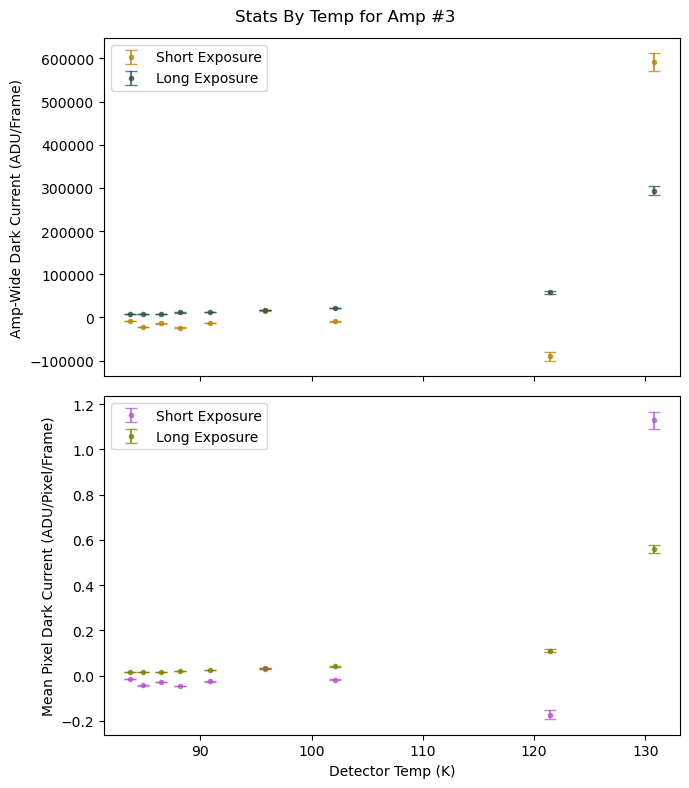

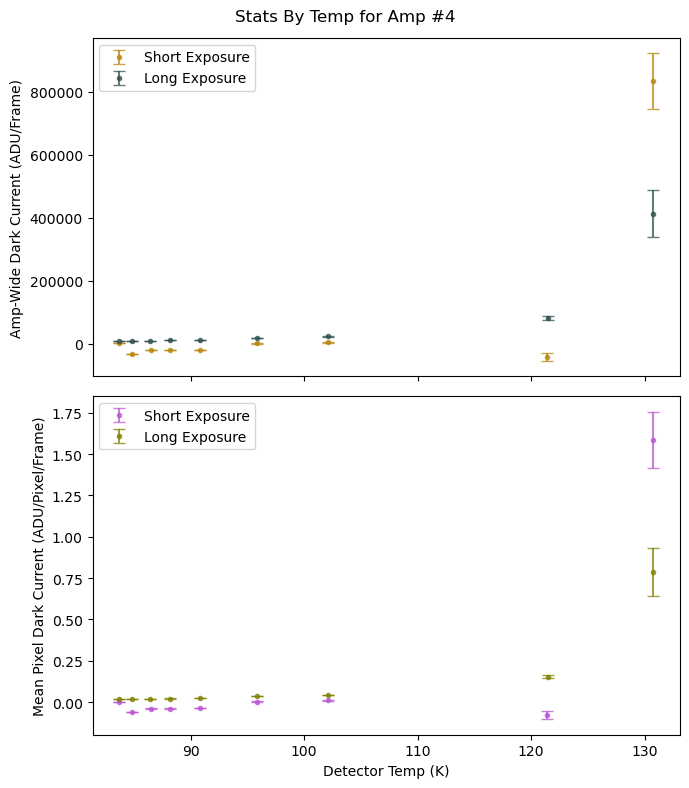

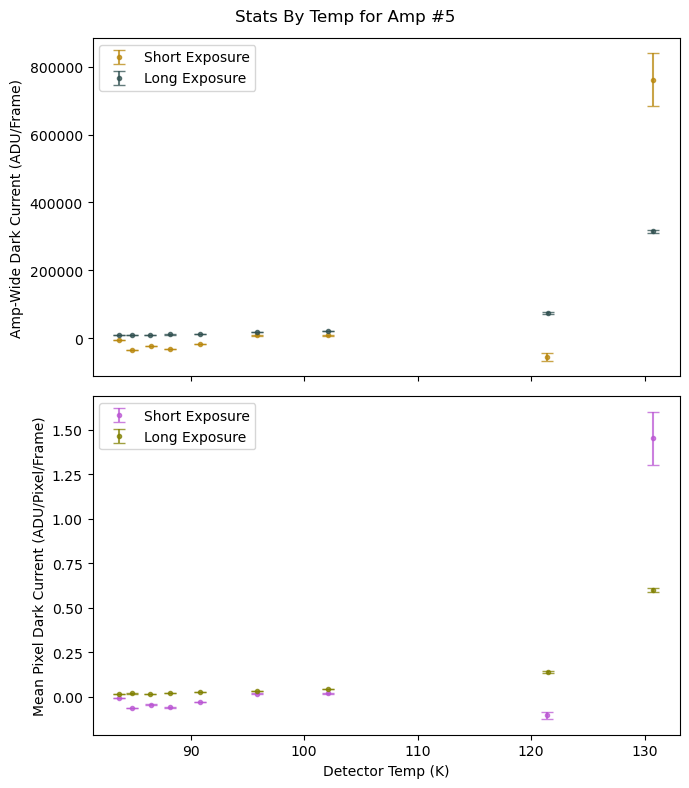

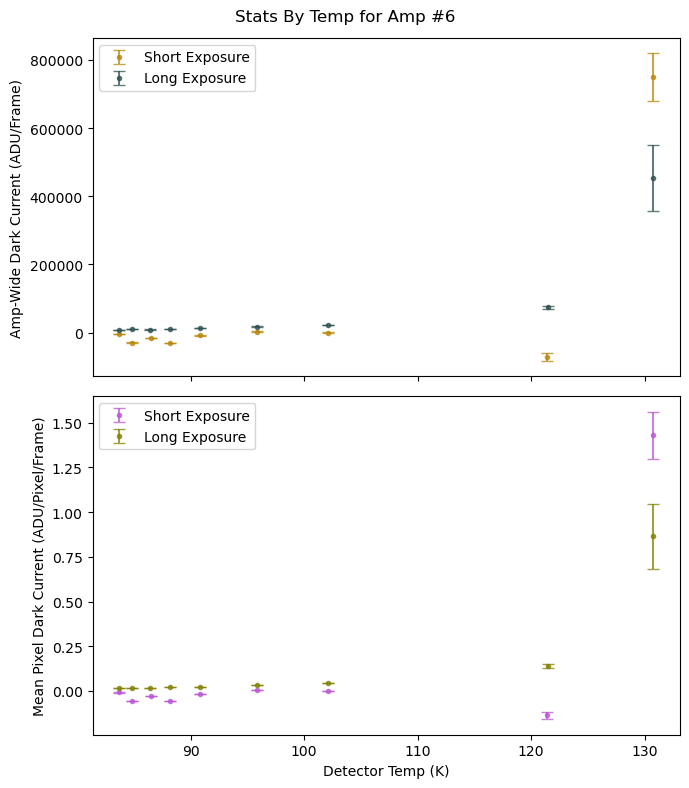

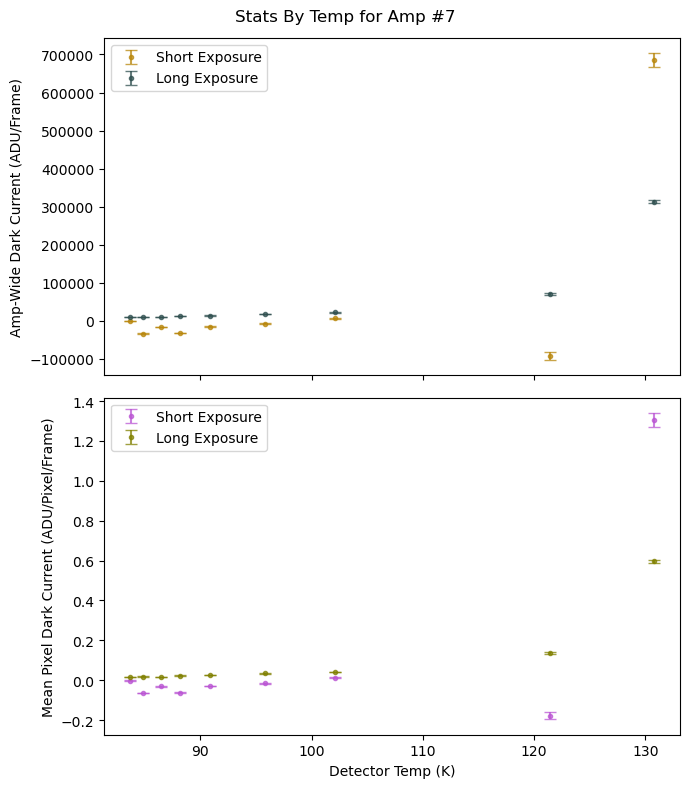

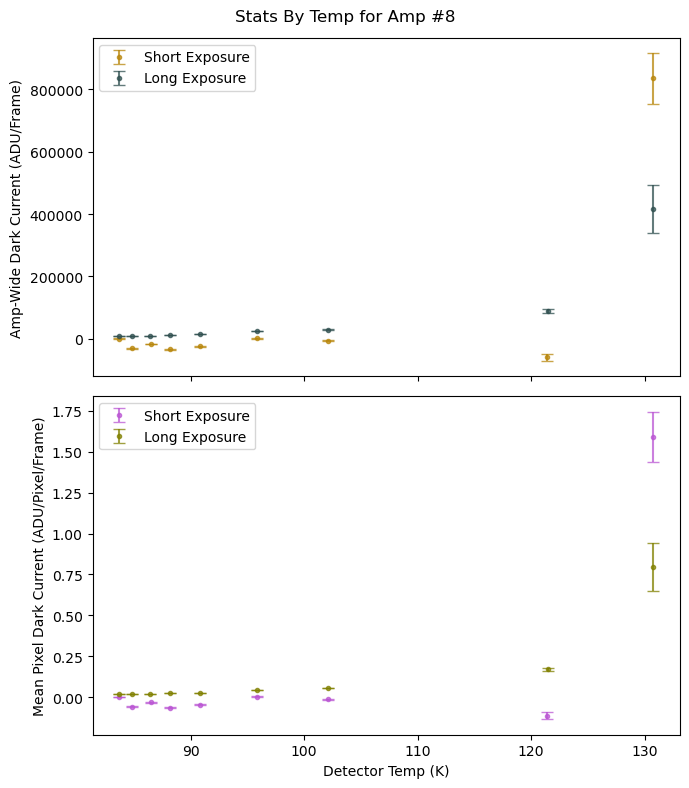

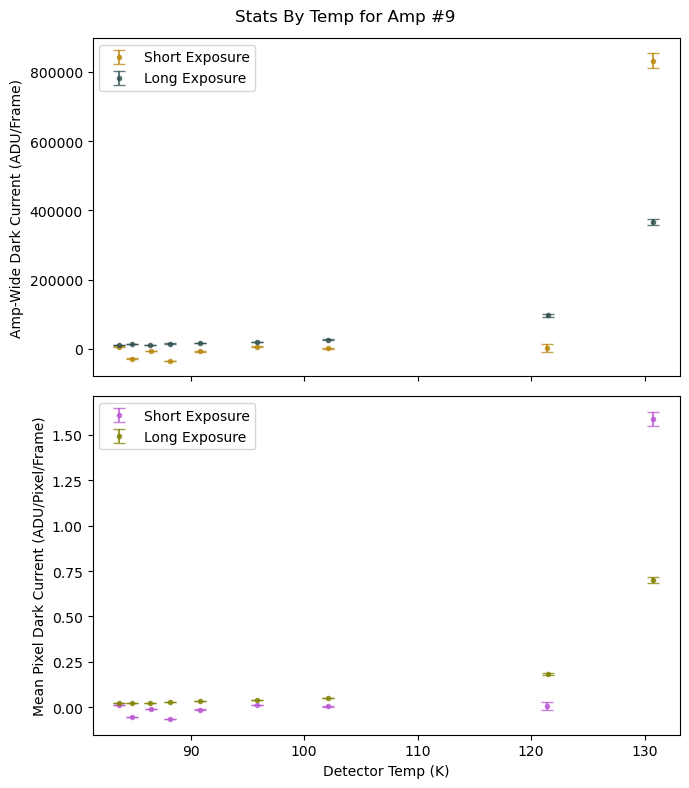

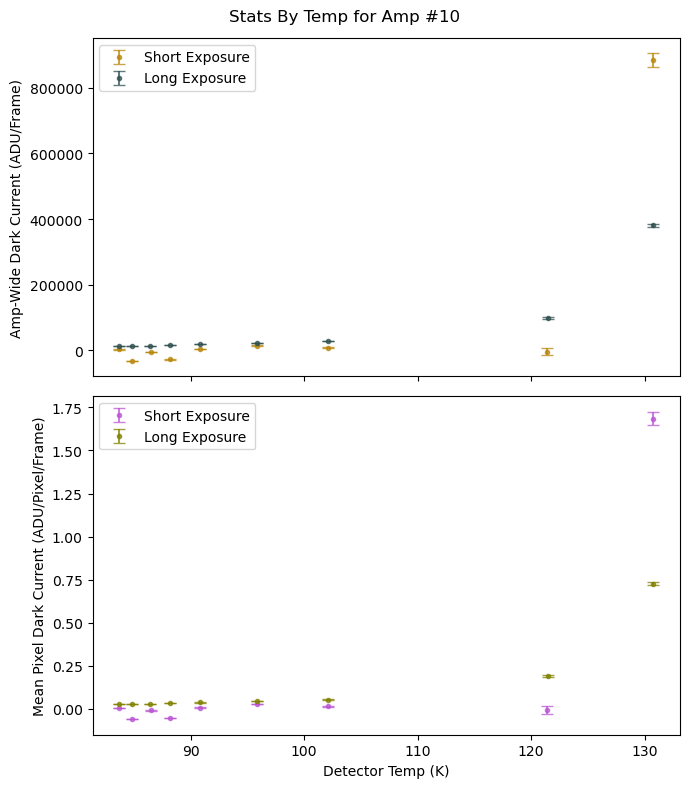

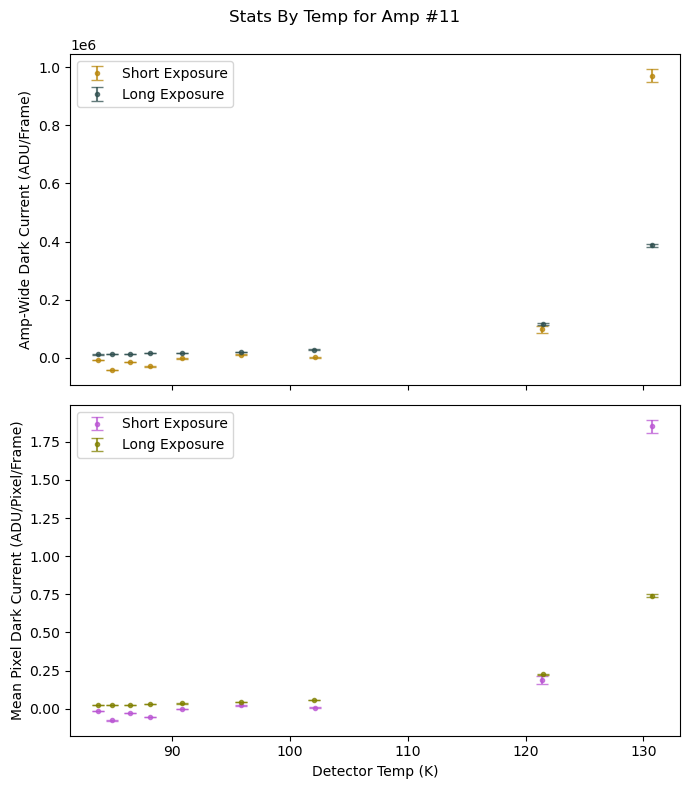

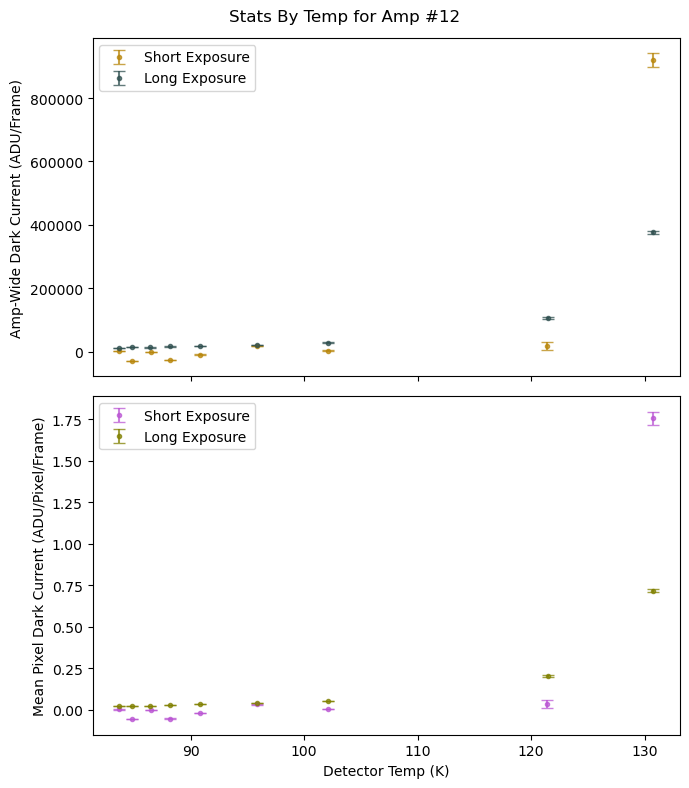

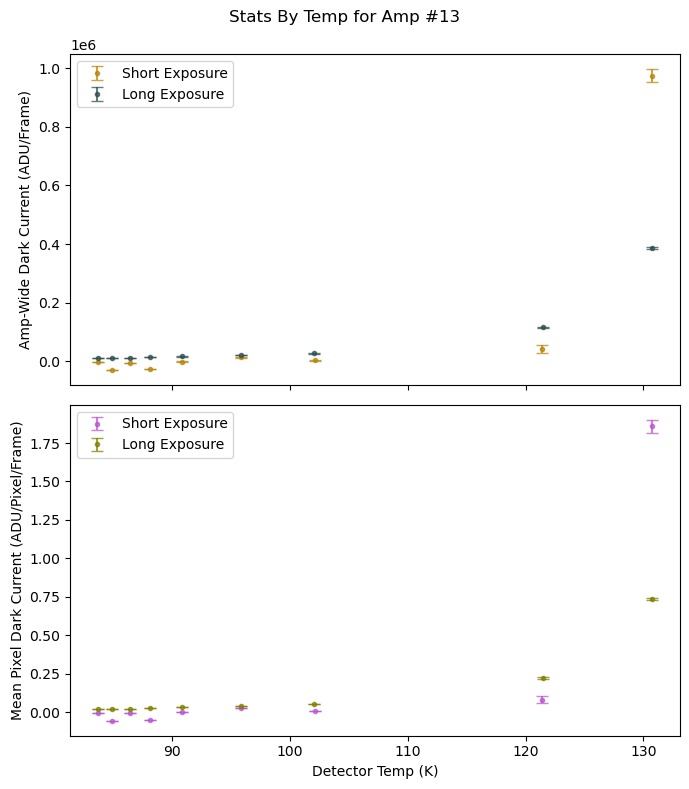

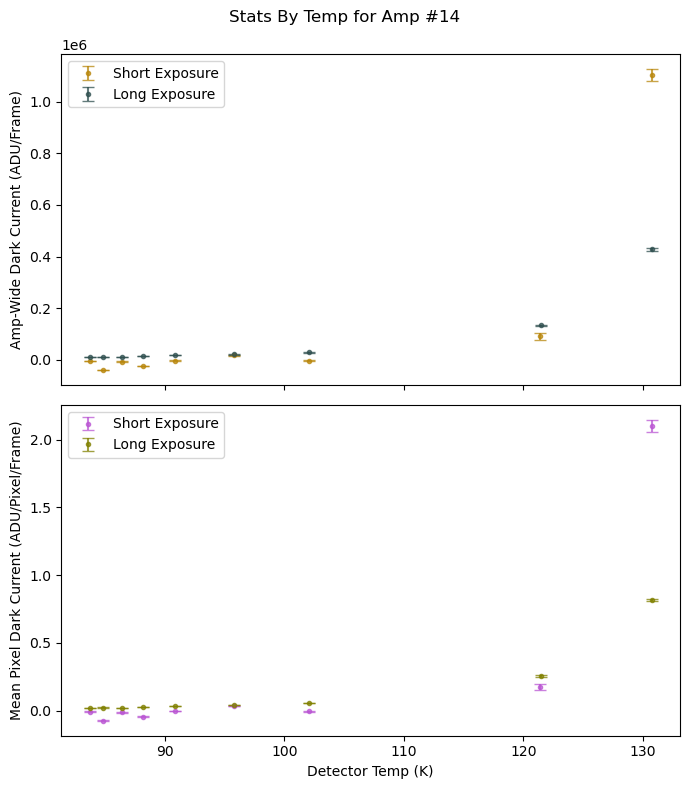

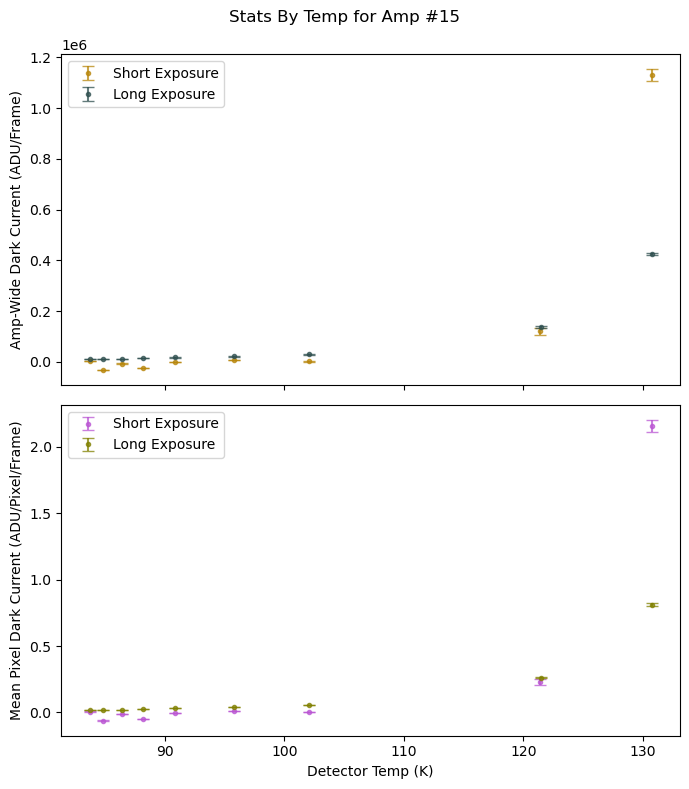

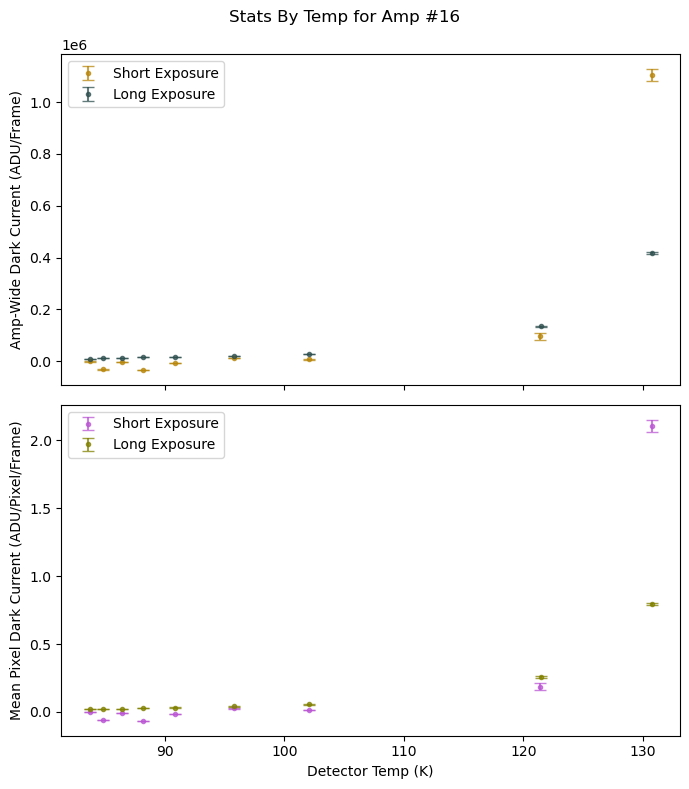

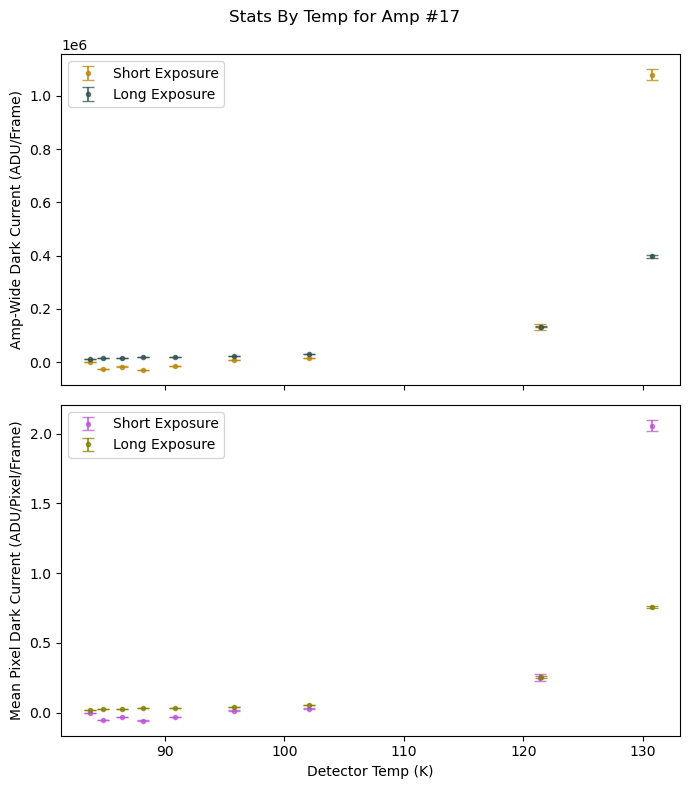

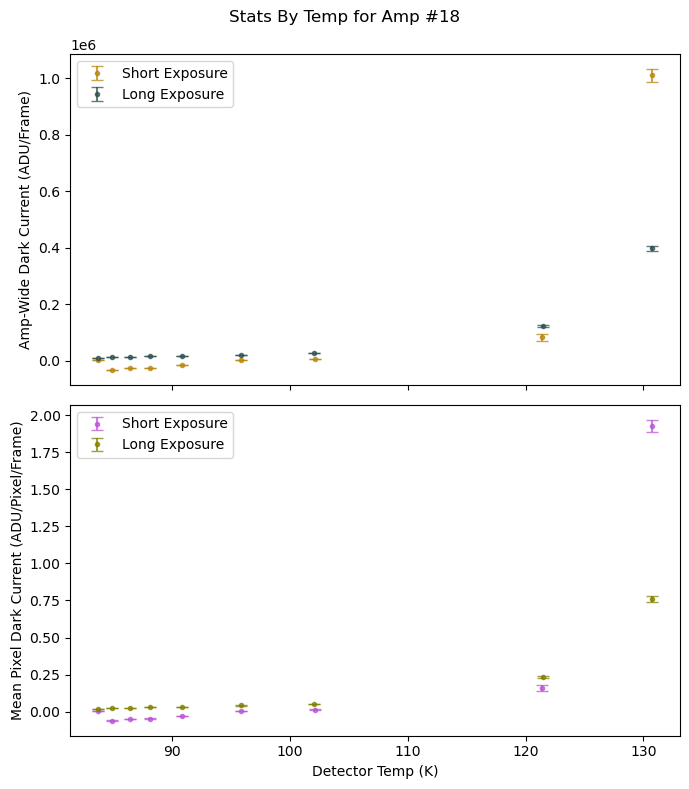

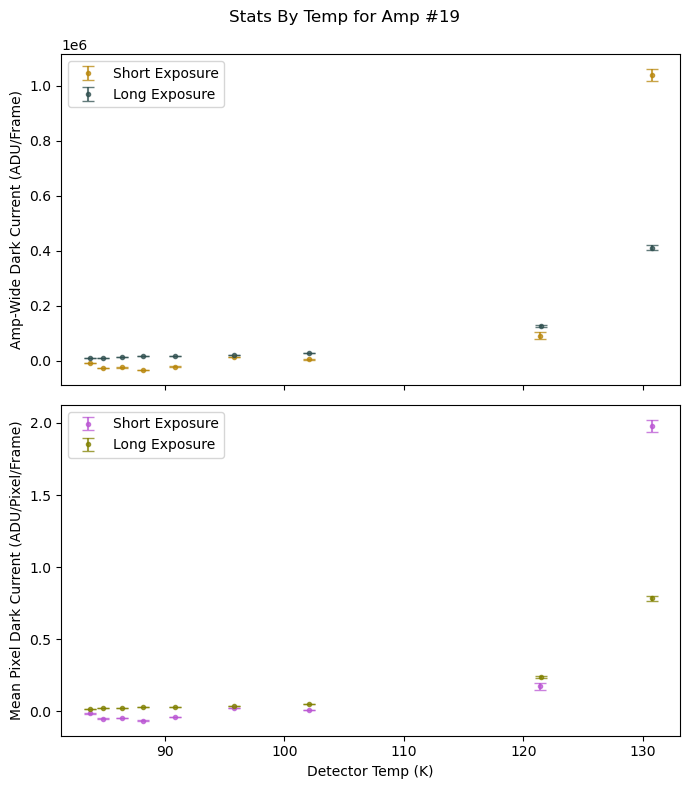

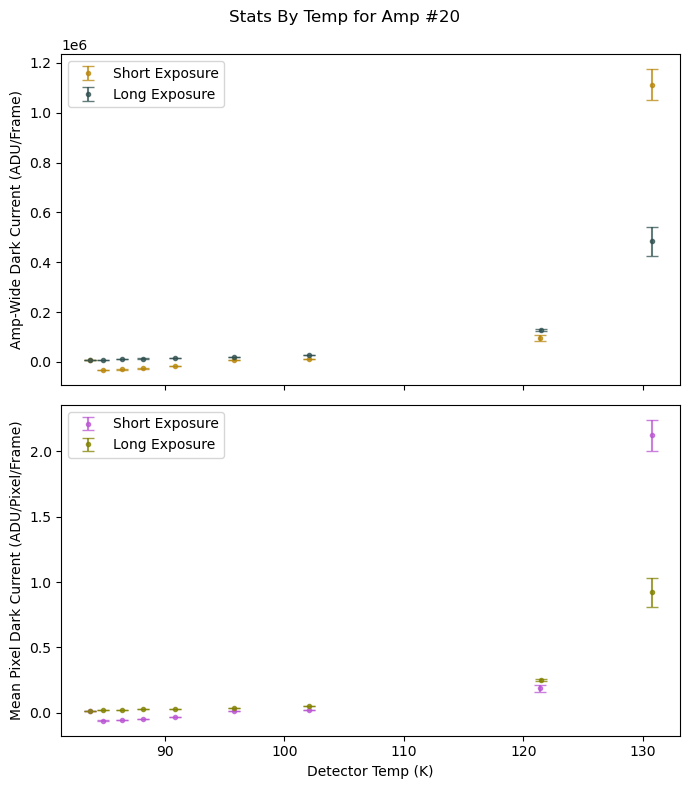

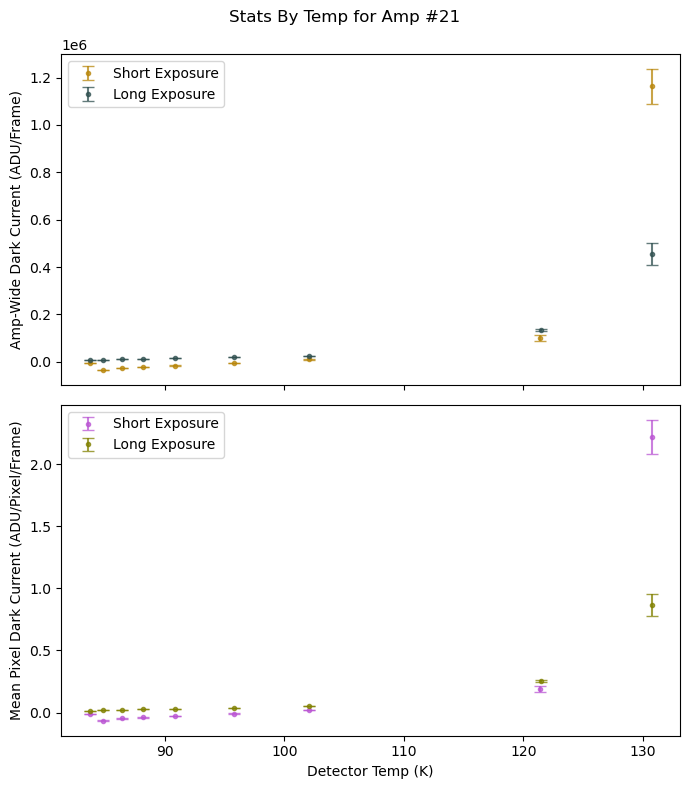

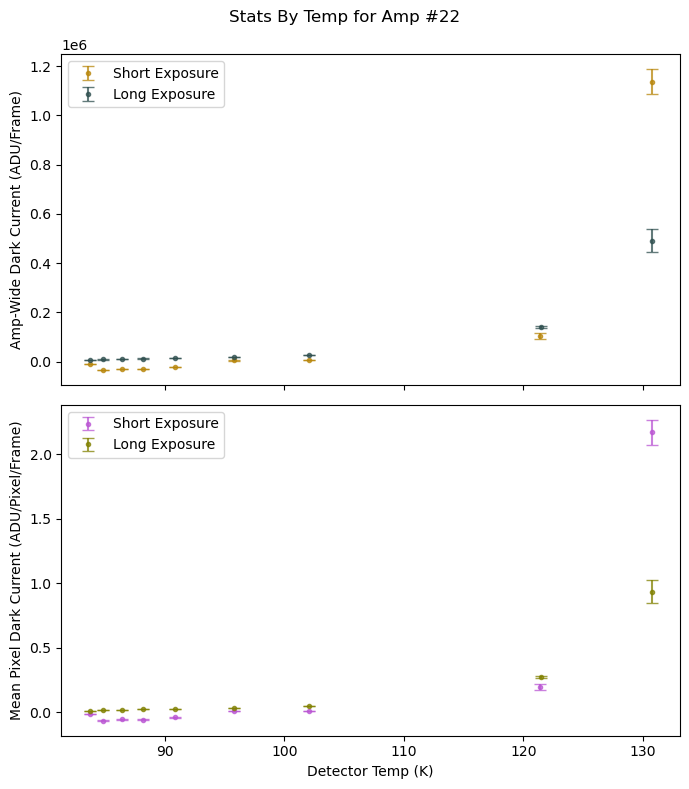

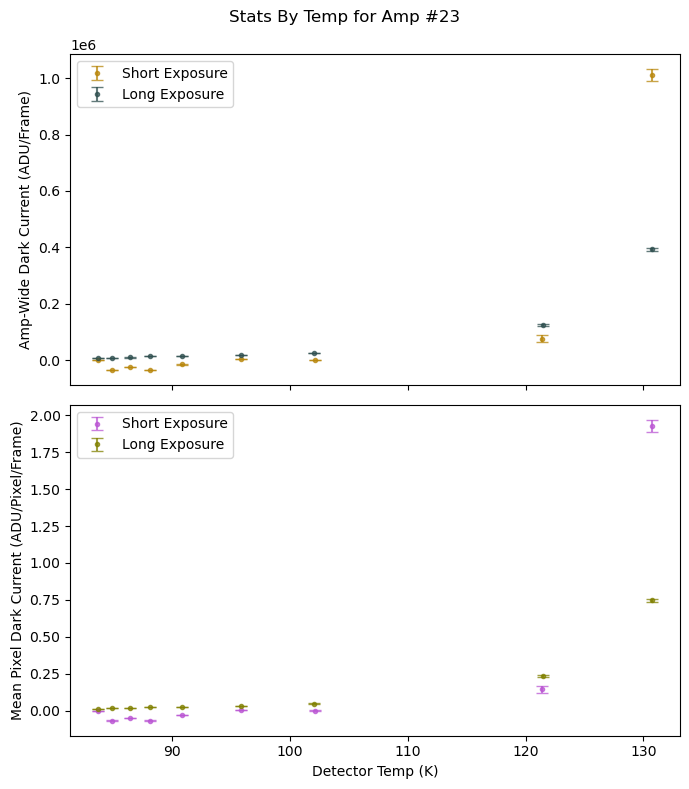

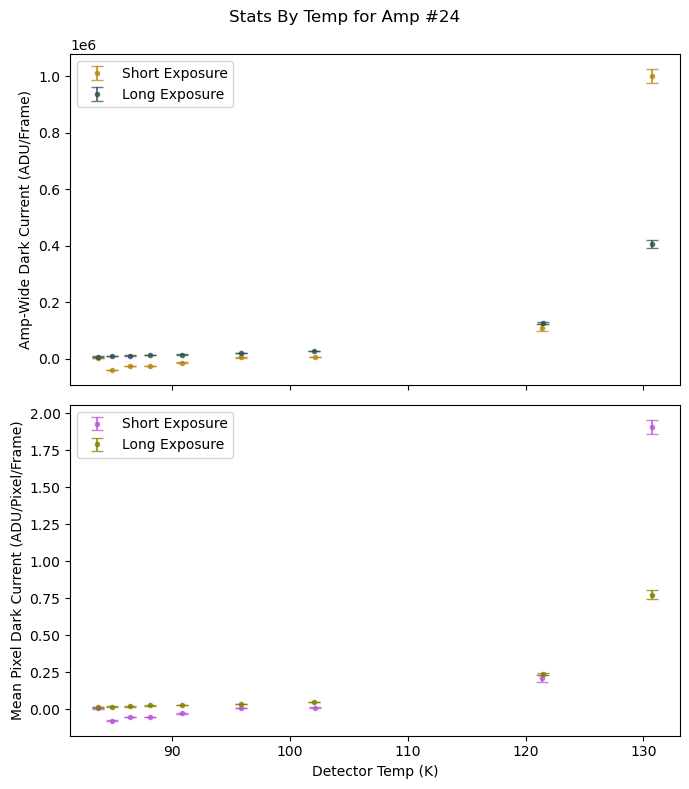

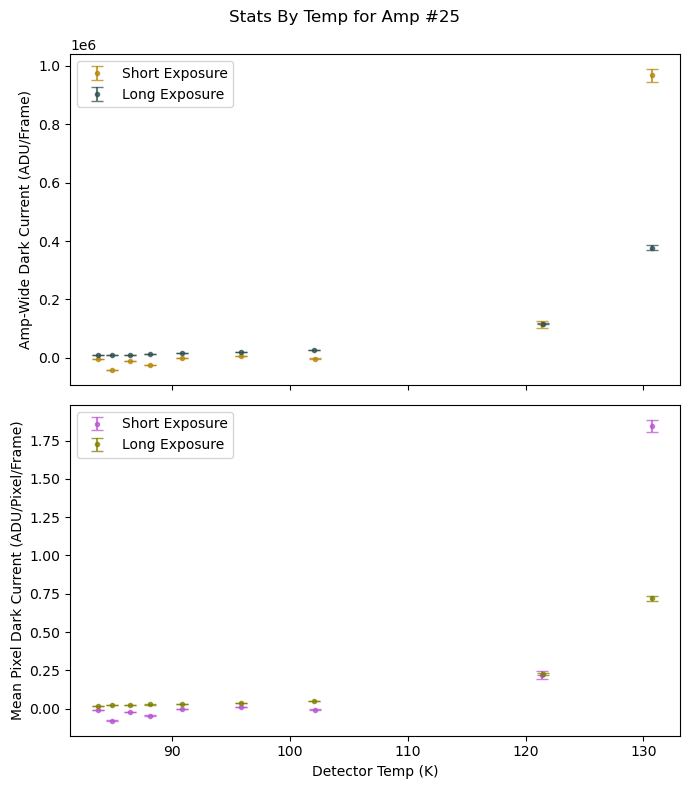

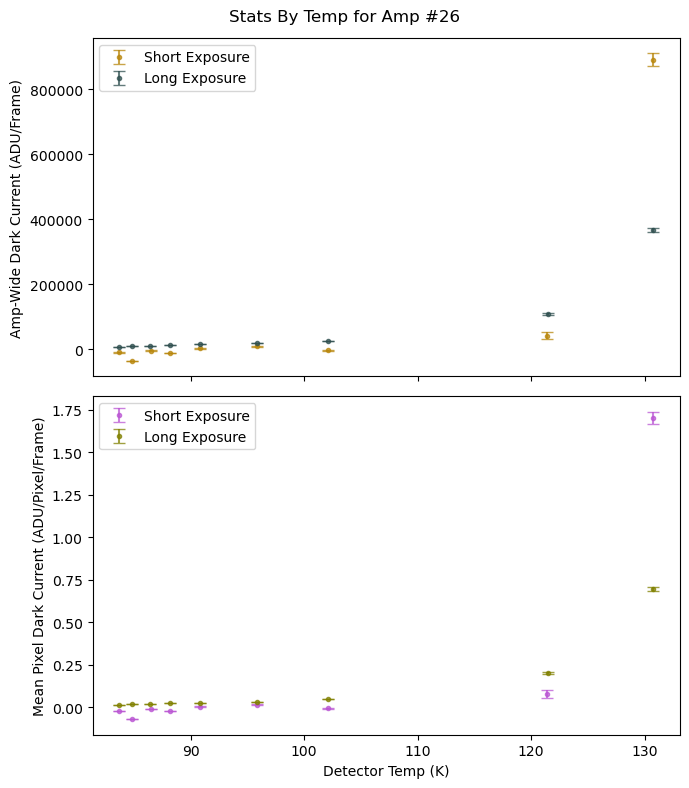

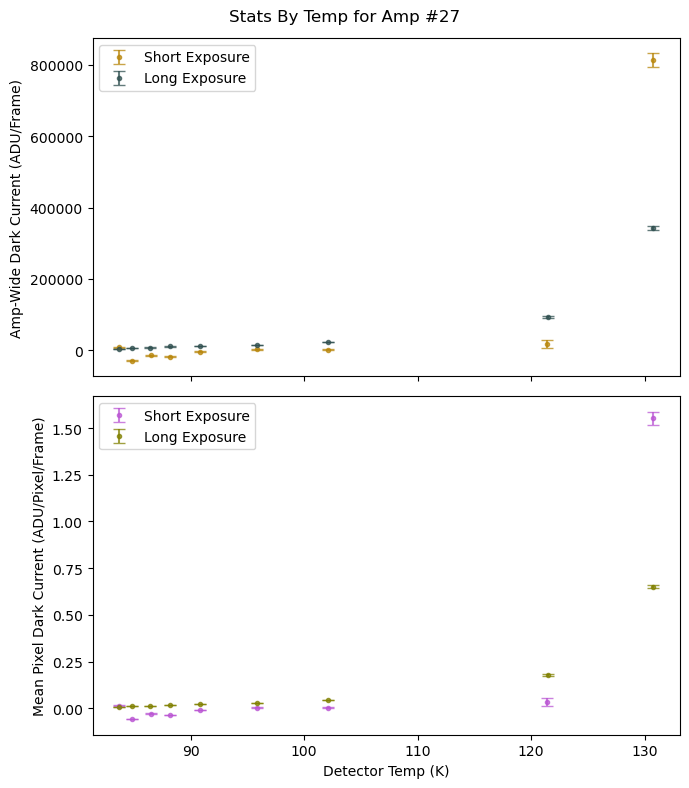

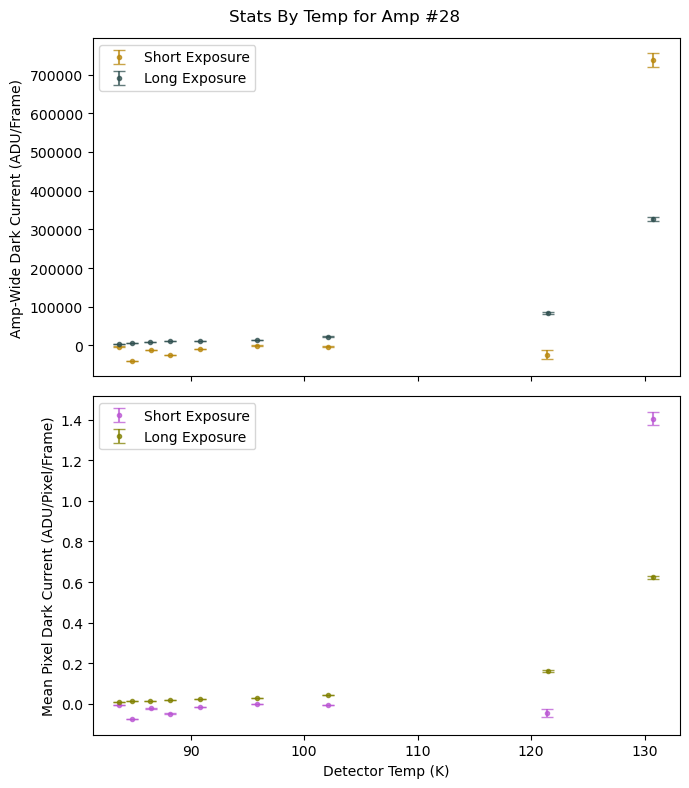

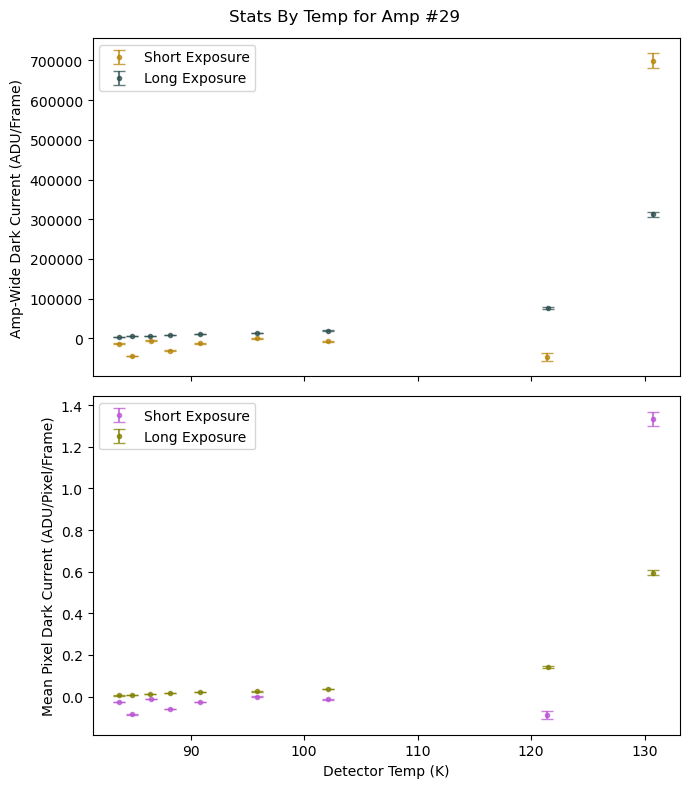

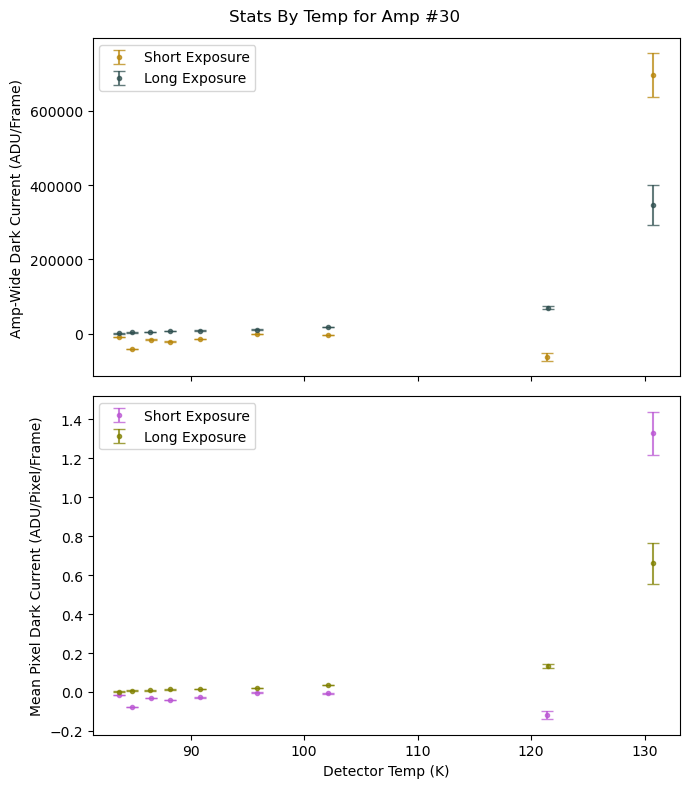

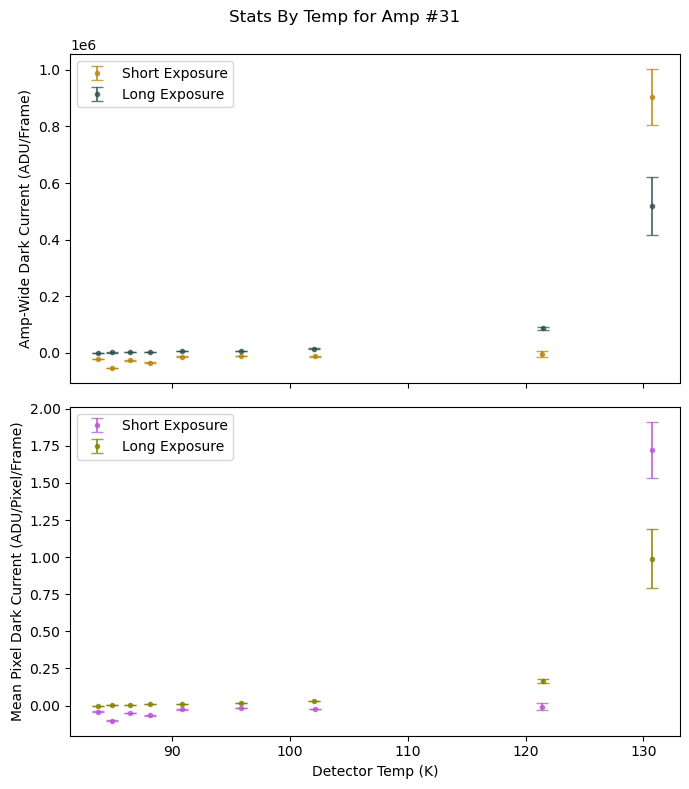

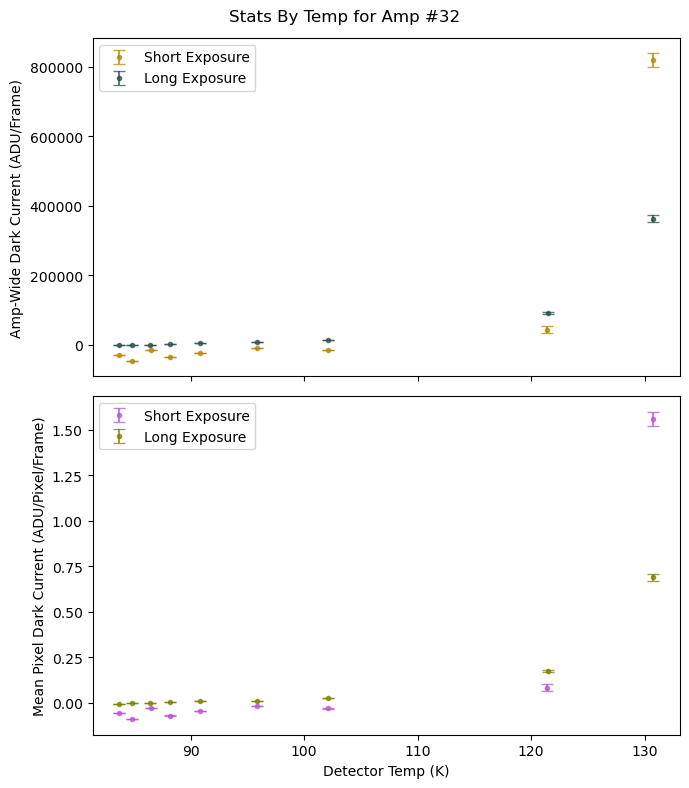

In [33]:
#generate plots for all 32 amps
for amp in range (1,33):
    plot_amp_vs_temp(df[df["Amp #"] == amp], amp, even, odd)